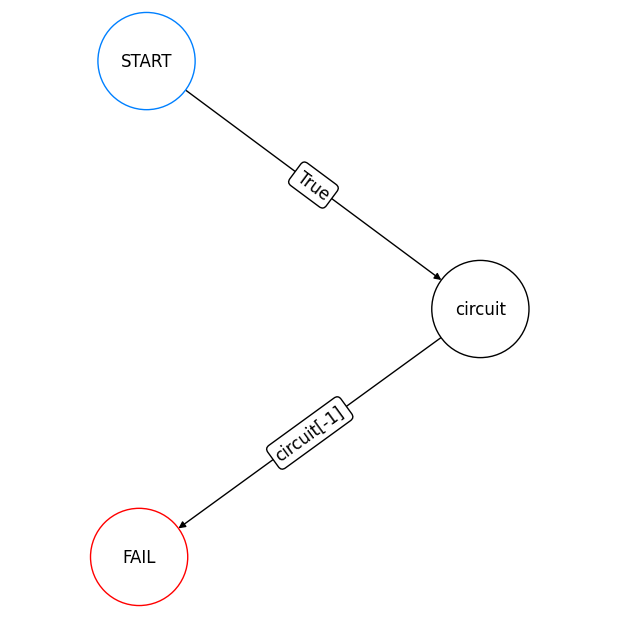

In [ ]:
import ast
import qsample as qs
import stim

class ProtocolTranslator(ast.NodeTransformer):
    def __init__(self, fault_tolerant=False):
        self.circuits = dict()
        self.mapping = {}
        
        self.last_circuit = None
        self.last_condition = None
        self.last_function_is_condition = False
        self.first_call = None
        self.current_node = None

        self.check_functions =[]
        self.protocol = qs.Protocol(check_functions=self.check_functions, fault_tolerant=fault_tolerant)

    def is_stim_circuit_def(node):
        if not isinstance(node, ast.Call):
            return False

        f = node.func
        return (
            isinstance(f, ast.Attribute)
            and isinstance(f.value, ast.Name)
            and f.value.id == "stim"
            and f.attr == "Circuit"
        )

    def is_stim_tableau_simulator(node: ast.AST) -> bool:
        if not isinstance(node, ast.Call):
            return False

        f = node.func
        return (
            isinstance(f, ast.Attribute)
            and isinstance(f.value, ast.Name)
            and f.value.id == "stim"
            and f.attr == "TableauSimulator"
        )

    def is_do_circuit(self, node):
        return (
            isinstance(node, ast.Call)
            and isinstance(node.func, ast.Attribute)
            and node.func.attr == "do_circuit"
        )
    
    def is_current_measurement(self, node):
        return (
            isinstance(node, ast.Call)
            and isinstance(node.func, ast.Attribute)
            and node.func.attr == "current_measurement_record"
        )
    
    def visit_Assign(self, node):
        self.collect_circuit(node.targets, node.value)
        if self.last_circuit and self.is_current_measurement(node.value):
            target = node.targets[0]
            if isinstance(target, ast.Name):
                self.mapping[target.id] = self.last_circuit
                self.last_circuit = None

        return self.generic_visit(node)

    def visit_If(self, node):
        self.last_function_is_condition = True
        self.generic_visit(node.test)

        cond_src = ast.unparse(node.test)
        self.last_condition=cond_src

        self.generic_visit(node)
        if node.orelse:
            cond_src = ast.unparse(node.test)
            self.last_condition="not "+cond_src
        
        
        return node

    def visit_Expr(self, node):
        if isinstance(node.value, ast.Call) and self.is_do_circuit(node.value):
            if node.value.args and isinstance(node.value.args[0], ast.Name):
                self.last_circuit = node.value.args[0].id

        return self.generic_visit(node)
    
    def visit_Return(self, node):
        if node.value.value == "FAIL":
            self.protocol.add_edge(self.current_node, "FAIL", check=self.last_condition)
        self.generic_visit(node)

    def visit_Call(self, node):
        if self.first_call is None:
            self.first_call = node

    def visit_Name(self, node):
        if node.id in self.mapping.keys():
            return ast.copy_location(ast.Name(id=self.mapping[node.id], ctx=node.ctx), node)
    
    def _contains_name(self, node, names):
        for n in ast.walk(node):
            if isinstance(n, ast.Name) and n.id in names:
                return n.id

    def collect_circuit(self, targets, value):
        if is_stim_circuit_def(value):
            for t in targets:
                if isinstance(t, ast.Name):
                    circuit_name=t.id

            if value.args and isinstance(value.args[0], ast.Constant) and isinstance(value.args[0].value, str):
                circuit_text = value.args[0].value
                try:
                    circuit = qs.Circuit().from_stim_circuit(circuit_text)
                    self.protocol.add_node(circuit_name, circuit=circuit)
                    if self.current_node is None:
                        self.protocol.add_edge("START", circuit_name, check="True")
                    self.current_node=circuit_name
                    
                except Exception as e:
                    print(f"Failed to parse stim.Circuit at line {value.lineno}: {e}")


code = """
sim = stim.TableauSimulator()
circuit = stim.Circuit('''X 0\nX_ERROR(0.1) 0\nM 0''')
sim.do_circuit(circuit)
result = sim.current_measurement_record()
if result[-1]:
    return "OK"
else:
    return "FAIL"

"""

def to_qsample_protocol(code):
    tree = ast.parse(code)
    collector = ProtocolTranslator()
    collector.visit(tree)
    return collector.protocol

ghz = to_qsample_protocol(code)
ghz.draw()
